Support Vector Regression (SVR) is the regression version of Support Vector Machines (SVMs). Instead of finding a hyperplane that separates classes, SVR finds a function that fits the data within a certain tolerance (called the ε-tube).

Constraint : |Y - wᵗx| <= ε  ,where Y is actual point and wᵗx is predicted point and ε is distance between hyperplane and marginal plane

                                  n
Cost Function : (||w|| / 2) + Ci  ∑ ϵi
                                 i=1
    where C is How many point we can adjust outside the marginal plane
          ϵ is the distance between marginal plane and actual data point

Constraint(for points that are outside the plane) : |Y - wᵗx| <= ε + |ϵi|

Limitations :
1.Not to use svr for very large datasets
2.Computational Complexity (Slow Training)
3.Scaling Requirement. You must standardize data (e.g., StandardScaler) before training
4.If data is extremely noisy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
x = df
y = data.target

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [5]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(np.array(y_train).reshape(-1,1))

In [6]:
regresson = SVR()

In [7]:
parameters = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.2, 0.5],
    "gamma": ["scale", "auto"]
}

In [8]:
gcv = GridSearchCV(regresson, parameters, cv=5, scoring="r2")

In [9]:
gcv.fit(x_train,y_train)

d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'epsilon': [0.1, 0.2, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [10]:
gcv.best_params_

{'C': 10, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}

In [11]:
print(gcv.best_score_)

0.7564961714154352


In [12]:
y_pred = gcv.predict(x_test)

In [13]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [14]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: -2.6666409727280267
MAE: 2.1165489262593624
MSE: 4.812613337659172


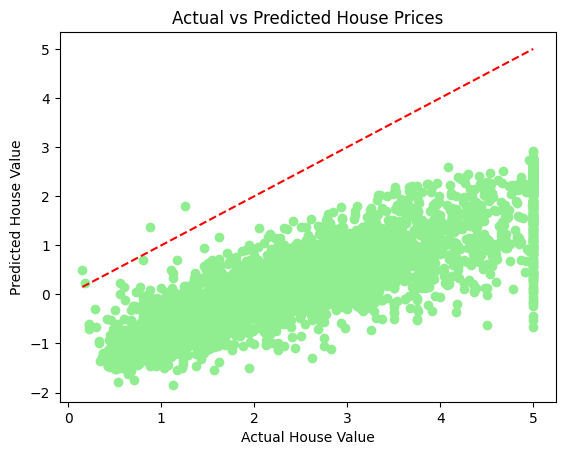

In [15]:
plt.scatter(y_test,y_pred,color="lightgreen")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linestyle="--")
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Prices')
plt.show()

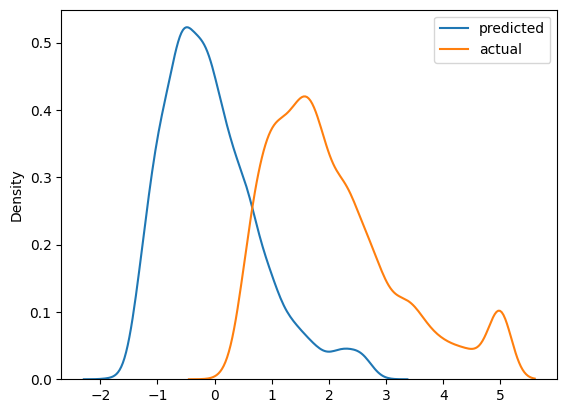

In [16]:
import seaborn as sns
sns.kdeplot(y_pred,label="predicted")
sns.kdeplot(y_test,label="actual")
plt.legend()

In [18]:
df.shape

(20640, 8)